In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("Dentistry Dataset.csv")

In [4]:
df

,Sl No,Sample ID,Age,Gender,inter canine distance intraoral,intercanine distance casts,right canine width intraoral,right canine width casts,left canine width intraoral,left canine width casts,right canine index intra oral,right canine index casts,left canine index intraoral,left canine index casts
0,1,NaN,24,Female,25.06,25.05,6.08,6.08,6.09,6.10,0.242,0.242,0.242,0.241
1,2,NaN,22,Female,25.78,25.79,6.13,6.13,6.33,6.33,0.237,0.237,0.247,0.247
2,3,NaN,23,Female,23.83,23.83,5.91,5.96,6.28,6.28,0.248,0.248,0.264,0.264
3,4,NaN,20,Female,26.12,26.12,6.08,6.08,6.56,6.56,0.232,0.232,0.250,0.250
4,5,NaN,20,Female,26.36,26.41,6.09,6.09,6.50,6.50,0.231,0.231,0.246,0.246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,1096,NaN,24,Male,24.29,24.29,6.58,6.58,6.60,6.60,0.271,0.271,0.272,0.272
1096,1097,NaN,22,Male,25.22,25.22,6.70,6.70,6.80,6.80,0.265,0.265,0.269,0.269
1097,1098,NaN,25,Male,24.24,24.24,6.60,6.60,6.61,6.61,0.272,0.272,0.272,0.272
1098,1099,NaN,21,Male,24.87,24.87,6.57,6.57,6.66,6.66,0.264,0.264,0.267,0.267


In [5]:
df.head()

,Sl No,Sample ID,Age,Gender,inter canine distance intraoral,intercanine distance casts,right canine width intraoral,right canine width casts,left canine width intraoral,left canine width casts,right canine index intra oral,right canine index casts,left canine index intraoral,left canine index casts
0,1,NaN,24,Female,25.06,25.05,6.08,6.08,6.09,6.10,0.242,0.242,0.242,0.241
1,2,NaN,22,Female,25.78,25.79,6.13,6.13,6.33,6.33,0.237,0.237,0.247,0.247
2,3,NaN,23,Female,23.83,23.83,5.91,5.96,6.28,6.28,0.248,0.248,0.264,0.264
3,4,NaN,20,Female,26.12,26.12,6.08,6.08,6.56,6.56,0.232,0.232,0.250,0.250
4,5,NaN,20,Female,26.36,26.41,6.09,6.09,6.50,6.50,0.231,0.231,0.246,0.246


In [6]:
df.isnull().sum()

Sl No                                 0
Sample ID                          1100
Age                                   0
Gender                                0
inter canine distance intraoral       0
intercanine distance casts            0
right canine width intraoral          0
right canine width casts              0
left canine width intraoral           0
left canine width casts               0
right canine index intra oral         0
right canine index casts              0
left canine index intraoral           0
left canine index casts               0
dtype: int64

In [7]:
data_clean=df.dropna()

In [8]:
data_clean

,Sl No,Sample ID,Age,Gender,inter canine distance intraoral,intercanine distance casts,right canine width intraoral,right canine width casts,left canine width intraoral,left canine width casts,right canine index intra oral,right canine index casts,left canine index intraoral,left canine index casts


In [12]:

df['Age'] = df['Age'].fillna(df['Age'].mean())


In [24]:

# Assuming 'Gender' has values 'Male' and 'Female'
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})



In [29]:

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])

In [30]:
from sklearn.preprocessing import LabelEncoder  

# Assuming 'inter canine distance intraoral' is the dependent variable (change it as per your target)
X = df.drop(columns=['inter canine distance intraoral', 'Sl No', 'Sample ID'])  # Independent variables
y = df['inter canine distance intraoral']  # Dependent variable


In [31]:
from sklearn.preprocessing import Normalizer

# Normalize the X variable
normalizer = Normalizer()
X_normalized = normalizer.fit_transform(X)

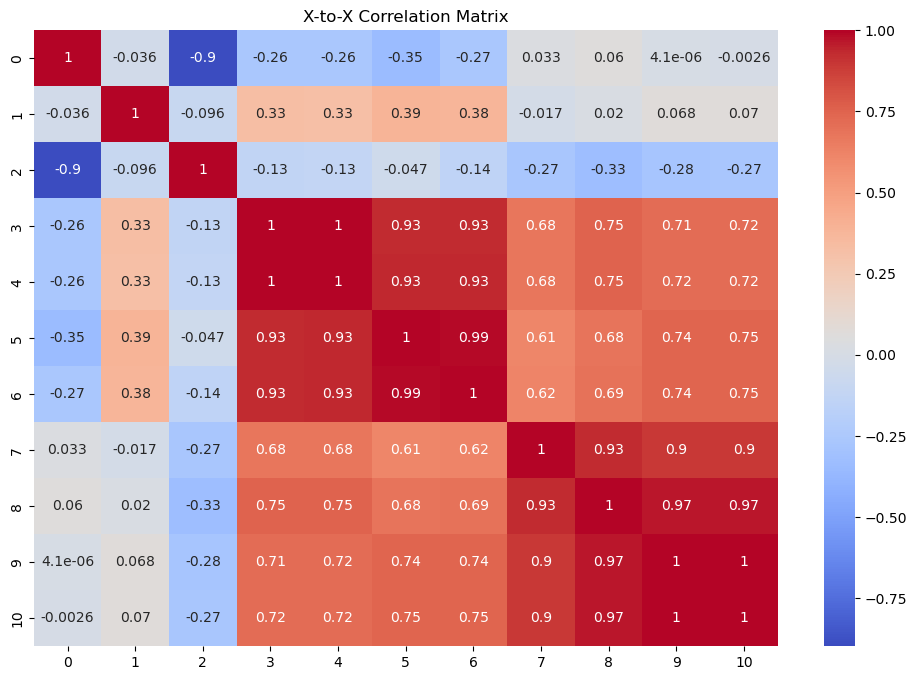

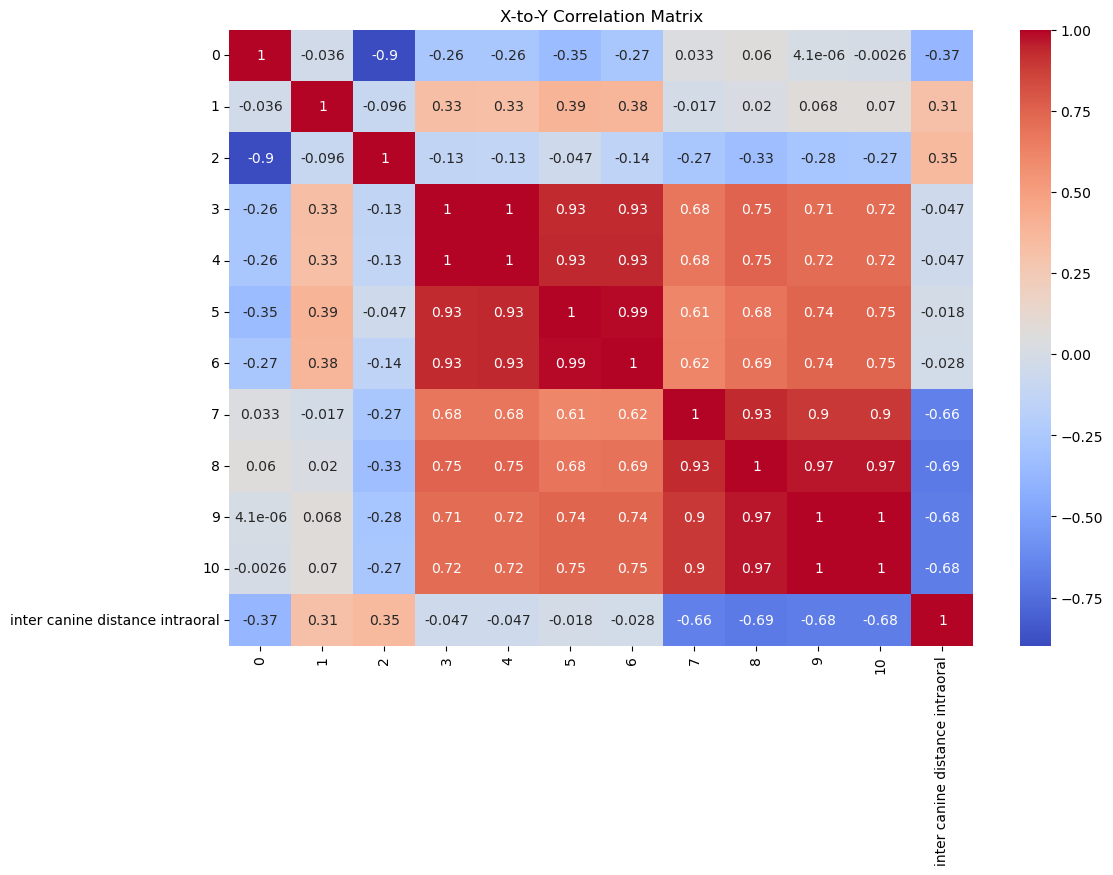

In [33]:

# Create a correlation matrix
correlation_matrix = pd.DataFrame(X_normalized).corr()

# Plot heatmap for X-to-X correlations
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('X-to-X Correlation Matrix')
plt.show()

# Check correlation between X and Y
df_corr = pd.concat([pd.DataFrame(X_normalized), y], axis=1)
plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title('X-to-Y Correlation Matrix')
plt.show()


In [38]:

X_selected = X.drop(columns=['right canine width intraoral','right canine width casts'])


In [39]:
X_selected

,Age,Gender,intercanine distance casts,left canine width intraoral,left canine width casts,right canine index intra oral,right canine index casts,left canine index intraoral,left canine index casts
0,24,0,25.05,6.09,6.10,0.242,0.242,0.242,0.241
1,22,0,25.79,6.33,6.33,0.237,0.237,0.247,0.247
2,23,0,23.83,6.28,6.28,0.248,0.248,0.264,0.264
3,20,0,26.12,6.56,6.56,0.232,0.232,0.250,0.250
4,20,0,26.41,6.50,6.50,0.231,0.231,0.246,0.246
...,...,...,...,...,...,...,...,...,...
1095,24,1,24.29,6.60,6.60,0.271,0.271,0.272,0.272
1096,22,1,25.22,6.80,6.80,0.265,0.265,0.269,0.269
1097,25,1,24.24,6.61,6.61,0.272,0.272,0.272,0.272
1098,21,1,24.87,6.66,6.66,0.264,0.264,0.267,0.267


In [40]:
from sklearn.model_selection import train_test_split

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


In [41]:
X_train,
X_test,
y_train,
y_test

(      Age  Gender  intercanine distance casts  left canine width intraoral  \
 507    22       0                       25.80                         6.38   
 551    24       0                       25.46                         5.93   
 290    24       0                       26.43                         6.26   
 2      23       0                       23.83                         6.28   
 6      21       0                       28.12                         6.84   
 ...   ...     ...                         ...                          ...   
 466    19       0                       25.16                         6.45   
 121    23       0                       24.68                         6.30   
 1044   23       1                       26.91                         7.27   
 1095   24       1                       24.29                         6.60   
 860    21       1                       25.74                         6.97   
 
       left canine width casts  right canine index